一、理解什么是Graph
Graph是LangGraph的基本构建模块，它是一个有向无环图（DAG），用于描述任务之间的依赖关系。
主要包含三个基本元素：
State:在整个应用中当做共享的一种数据结构
Node：一个处理数据的节点，LangGraph中通常是一个Python函数,以State为输入，经过一些操作后，输出新的State
Edge：表示Node之间的依赖关系，LangGraph中通常也是一个Python函数，根据当前的State来决定接下来执行哪个Node

In [1]:
from typing import TypedDict
from langgraph.constants import END,START
from langgraph.graph import StateGraph

class InputState(TypedDict):
    user_input: str

class OutputState(TypedDict):
    graph_output: str

class OverallState(TypedDict):
    foo: str
    input_state: InputState
    output_state: OutputState

class PrivateState(TypedDict):
    bar: str

def node_1(state:InputState)->OverallState:
    # write to OverallState
    return {"foo": state["user_input"] + "学院"}

def node_2(state:OverallState)->PrivateState:
    # read from OverallState,write to PrivateState
    return {"bar": state["foo"] + "非常"}

def node_3(state:PrivateState)->OutputState:
    # read from PrivateState,write to OutputState
    return {"graph_output": state["bar"] + "靠谱"}

# 构建图
builder = StateGraph(OverallState,input=InputState,output=OutputState)
# Node
builder.add_node("node_1",node_1)
builder.add_node("node_2",node_2)
builder.add_node("node_3",node_3)
# Edge
builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")
builder.add_edge("node_2","node_3")
builder.add_edge("node_3",END)
# 编译图
graph = builder.compile()
# 调用图
graph.invoke({"user_input":"人工智能"})


C:\Users\23272\AppData\Local\Temp\ipykernel_14628\520689895.py:32: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState,input=InputState,output=OutputState)
C:\Users\23272\AppData\Local\Temp\ipykernel_14628\520689895.py:32: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState,input=InputState,output=OutputState)


{'graph_output': '人工智能学院非常靠谱'}

这个案例当中，请求的参数从固定的START传入，依次经过三个节点处理，每个节点的处理都会被保存到不同的state当中，最后进入END节点结束。
如果你觉得这个流程不够明显，还可以直接用真正的图来看看请求是如何处理的。



1、State状态
State是所有节点共享的状态。它是一个字典，包含了所有节点的状态。有几个需要注意的地方：
    ·State形式上，可以是TypeDict字典，也可以是Pydantic中的一个BaseModel。例如：
from pydantic import BaseModel
class OverallState(BaseModel):
    a:str
这两种实现，本质并没有太多的区别。
    ·State中定义的属性，通常不需要指定默认值，如果需要默认值，可以通过在START节点后定义一个node来指定默认值。
def node(state:OverallState):
    return {"a":"bye"}
    ·State中的属性，除了可以修改值之外，也可以定义一些操作，来指定如何更新State中的值。例如：
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    list_filed:Annotated[list[int],add]
    extra_filed:int     
此时，如果有一个node，返回了State中更新的值，那么messages和list_filed会自动进行累加，而extra_filed会被替换。

In [4]:
from langchain_core.messages import AnyMessage, AIMessage
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict
from operator import add

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    list_filed:Annotated[list[int],add]
    extra_filed:int     # 每到一个节点会被替换

def node_1(state:State):
    new_message = AIMessage(content="你好")
    return {"messages": [new_message],"list_filed":[10],"extra_filed":10}

def node_2(state:State):
    new_message = AIMessage("LangGraph")
    return {"messages": [new_message],"list_filed":[20],"extra_filed":20}

graph = (StateGraph(State)
    .add_node("node_1",node_1)
    .add_node("node_2",node_2)
    .set_entry_point("node_1")
    .add_edge("node_1","node_2")
    .compile()
)

input_message = {"role":"user", "content": "Hi"}

result = graph.invoke({"messages":[input_message],"list_filed":[1, 2, 3]})

print(result)


{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='cd959f9c-ad94-4e2a-88e5-490b16420c6c'), AIMessage(content='你好', additional_kwargs={}, response_metadata={}, id='004df9f0-311c-479d-9ddb-c42df95f8b6c'), AIMessage(content='LangGraph', additional_kwargs={}, response_metadata={}, id='a906b465-ba26-4dd9-b132-751cd166dd6a')], 'list_filed': [1, 2, 3, 10, 20], 'extra_filed': 20}


2、Node 节点
Node是图中的一个处理数据的节点。也有以下几个需要注意的地方：
- 在LangGraph中，Node通常是一个Python的函数，它接受一个State对象作为输入，返回一个State对象作为输出。
- 每个Node都有一个唯一的名称，通常是一个字符串。如果没有提供名称，LangGraph会自动生成一个和函数名一样的名称。
- 在具体实现时，通常包含两个具体的参数：第一个是State，这个是必选的。第二个是一个可选的配置项config，这里面包含了一些节点运行的配置参数。
- LangGraph对每个Node提供了缓存机制。只要Node的传入参数相同，LangGraph就会优先从缓存当中获取Node的执行结果，从而提升Node的运行速度。

In [ ]:
import time
from typing import TypedDict

from langchain_core.runnables import RunnableConfig
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import CachePolicy
from langgraph.cache.memory import InMemoryCache  # 是langgraph中的，而不是langchain中的。

# 配置状态
class State(TypedDict):
    number: int
    user_id: str

# 配置信息
class ConfigSchema(TypedDict):
    user_id: str

def node_1(state: State, config: RunnableConfig):
    time.sleep(3)
    user_id = config["configurable"]["user_id"]
    return {"number": state["number"] + 1, "user_id": user_id}

builder = StateGraph(State, config_schema=ConfigSchema)
# Node缓存5秒
builder.add_node("node1", node_1, cache_policy=CachePolicy(ttl=5))
builder.add_edge(START, "node1")

graph = builder.compile(cache=InMemoryCache())
print(graph.invoke({"number": 5}, config={"configurable": {"user_id": "123"}},stream_mode='updates'))
# [{'node1:{'number':6,'user_id':'123'}}]
# node入参相同，就会走缓存
print(graph.invoke({"number": 5}, config={"configurable": {"user_id": "456"}},stream_mode='updates'))   
# [{'node1:{'number':6,'user_id':'123'},'__metadtat__':{'cache_hit':True}}]
print(graph.invoke({"number": 6}, config={"configurable": {"user_id": "456"}},stream_mode='updates'))
# [{'node1': {'number': 7, 'user_id': '456'}}]

C:\Users\23272\AppData\Local\Temp\ipykernel_14628\1240986277.py:24: LangGraphDeprecatedSinceV10: `config_schema` is deprecated and will be removed. Please use `context_schema` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  builder = StateGraph(State, config_schema=ConfigSchema)


[{'node1': {'number': 6, 'user_id': '123'}}]
[{'node1': {'number': 6, 'user_id': '123'}, '__metadata__': {'cached': True}}]
[{'node1': {'number': 7, 'user_id': '456'}}]


- 对于Node, LangGraph除了提供缓存机制，还提供了重试机制。
可以针对单个节点指定，例如：
from langgraph.types import RetryPolicy
builder.add_node("node1", node_1, retry=RetryPolicy(max_attempts=4)) 
 
 
另外，也可以针对某一次任务调用指定，例如
print(graph.invoke(xxxxxx, config={"recursion_limit":25})) 

3、Edge 边
 
在Graph图中，通过Edge(边)把Node(节点)连接起来，从而决定State应该如何在Graph中传递。LangGraph中也提供了非常灵活的构建方式。
- 普通Edge和EntryPoint
  Edge通常是用来把两个Node连接起来，形成逻辑处理路线。例如  graph.add_edge("node_1","node_2") 。
  LangGraph中提供了两个默认的Node，START和END，用来作为Graph的入口和出口。
  同时，也可以自行指定Entry Point，例如:
builder = StateGraph(State)
builder.set_entry_point("node1") 
builder.set_finish_point("node2") 
 
 
- 条件边Edge和EntryPoint
  我们也可以添加带有条件判断的Edge和EntryPoint，用来动态构建更复杂的工作流程。
  具体实现时，可以指定一个函数，函数的返回值就可以是下一个Node的名称。

In [ ]:
from typing import TypedDict
from langchain_core.runnables import RunnableConfig
from langgraph.constants import START, END
from langgraph.graph import StateGraph

# 配置状态
class State(TypedDict):
    number: int

def node_1(state: State, config: RunnableConfig):
    return {"number": state["number"] + 1}

builder = StateGraph(State)
# Node缓存5秒（图中代码写的是添加节点，未体现缓存，按实际提取）
builder.add_node("node1", node_1)

def routing_func(state: State) -> str:
    if state["number"] > 5:
        return "node1"
    else:
        return END

builder.add_edge("node1", END)

builder.add_conditional_edges(START, routing_func)  # routing_func条件判断

graph = builder.compile()
print(graph.invoke({"number":6}))
# {'number': 7}
print(graph.invoke({"number":4}))
# {'number': 4}

{'number': 7}
{'number': 4}


另外，如果不想在路由函数中写入过多具体的节点名称，也可以在函数中返回一个自定义的结果，然后将这个结果解析到某一个具体的Node上。例如
 
def routing_func (state:State) -> bool:
    if state["number"] > 5:
        return True
    else:
        return False

builder.add_conditional_edges( START, routing_func,{True:"node_a", False: "node_b"})
 
 
- Send动态路由
在条件边中，如果希望一个Node后同时路由到多个Node，就可以返回Send动态路由的方式实现。
 
Send对象可传入两个参数，第一个是下一个Node的名称，第二个是Node的输入。

In [10]:
from operator import add
from typing import TypedDict, Annotated
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send

class State(TypedDict):
    messages:Annotated[list[str], add]

class PrivateState(TypedDict):
    msg: str

def node_1(state: PrivateState) -> State:
    res = state["msg"] + "!"
    return {"messages": [res]}


builder = StateGraph(State)
# Node缓存5秒
builder.add_node("node1", node_1)


def routing_func(state: State):
    result = []
    for message in state["messages"]:
        result.append(Send("node1", {"msg": message}))
    return result


# 通过路由函数，将消息中每个字符串分别传入node1处理。
builder.add_conditional_edges(START, routing_func, ["node1"])
builder.add_edge("node1", END)


graph = builder.compile()
print(graph.invoke({"messages": ["hello", "world", "hello", "graph"]}))
# {'messages': ['hello!', 'world!', 'hello!', 'graph!', 'hello!!', 'world!!', 'hello!!', 'graph!!']}

{'messages': ['hello', 'world', 'hello', 'graph', 'hello!', 'world!', 'hello!', 'graph!']}


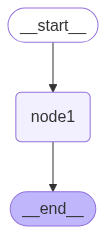

In [13]:
# 补充看一下Graph的结构
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Command命令
 
通常，Graph中一个典型的业务步骤是State进入一个Node处理。在Node中先更新State状态，然后再通过Edges传递给下一个Node。如果希望将这两个步骤合并为一个命令，那么还可以使用Command命令。

In [12]:
from operator import add
from typing import TypedDict, Annotated

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Command

# 配置状态
class State(TypedDict):
    messages: Annotated[list[str], add]

def node_1(state: State):
    new_message = []
    for message in state["messages"]:
        new_message.append(message + "!")
    return Command(
        goto=END,
        update={"messages": new_message}
    )

builder = StateGraph(State)
builder.add_node("node1", node_1)
# node1中通过Command同时集成了更新State和指定下一个Node
builder.add_edge(START, "node1")

graph = builder.compile()
print(graph.invoke({"messages": ["hello", "world", "hello", "graph"]}))
# {'messages': ['hello', 'world', 'hello', 'graph', 'hello!', 'world!', 'hello!', 'graph!']}

{'messages': ['hello', 'world', 'hello', 'graph', 'hello!', 'world!', 'hello!', 'graph!']}


4、子图
在 LangGraph 中，一个 Graph 除了可以单独使用，还可以作为一个 Node，嵌入到另一个 Graph 中，这种用法就称为子图。通过子图，我们可以更好地复用 Graph，构建更复杂的工作流，尤其在构建多 Agent 系统中非常有用。在大型项目中，通常都是由一个团队专门开发 Agent，再通过其他团队来完整 Agent 整合。
使用子图时，基本和使用 Node 没有太多的区别。
唯一需要注意的是，当触发了 SubGraph 代表的 Node 后，实际上是相当于重新调用了一次  subgraph.invoke(state)  方法。

In [14]:
# subgraph与graph使用相同State
from operator import add
from typing import TypedDict, Annotated

from langgraph.constants import END
from langgraph.graph import StateGraph, MessagesState, START

class State(TypedDict):
    messages: Annotated[list[str], add]

# Subgraph
def sub_node_1(state: State) -> MessagesState:
    return {"messages": ["response from subgraph"]}

subgraph_builder = StateGraph(State)
subgraph_builder.add_node("sub_node_1", sub_node_1)
subgraph_builder.add_edge(START, "sub_node_1")
subgraph_builder.add_edge("sub_node_1", END)

subgraph = subgraph_builder.compile()

# Parent graph
builder = StateGraph(State)
builder.add_node("subgraph_node", subgraph)
builder.add_edge(START, "subgraph_node")
builder.add_edge("subgraph_node", END)
graph = builder.compile()

print(graph.invoke({"messages": ["hello subgraph"]}))
# 结果hello subgraph会出现两次，这是因为在subgraph_node中默认调用了一次subgraph.invoke(state)方法，主图里也调用了一次invoke，这就会往state里添加两次语句
# {'messages': ['hello subgraph', 'hello subgraph', 'response from subgraph']}

{'messages': ['hello subgraph', 'hello subgraph', 'response from subgraph']}


5、图的Stream支持
 
和调用大模型相似，Graph 除了可以通过 invoke 方法进行直接调用外，也支持通过 stream() 方法进行流式调用。不过大模型的流式调用是依次返回大模型响应的 Token，而 Graph 的流式输出则是依次返回数据处理步骤。
graph 提供了 stream() 方法进行同步的流式调用，也提供了 astream() 方法进行异步的流式调用。

In [18]:
for chunk in graph.stream({"messages": ["hello subgraph"]}, stream_mode="messages"):
    print(chunk)
# updates: {'subgraph_node': {'messages': ['hello subgraph', 'response from subgraph']}}
# values: {'messages': ['hello subgraph']}
#         {'messages': ['hello subgraph', 'hello subgraph', 'response from subgraph']}

LangGraph 支持几种不同的 stream mode：
 
- values: 在图的每一步之后流式传输状态的完整值。
- updates: 在图的每一步之后，将更新内容流式传输到状态。如果在同一步骤中进行了多次更新（例如，运行了多个节点），这些更新将分别进行流式传输。
- custom: 从图节点内部流式传输自定义数据。通常用于调试。
- messages: 从任何调用大语言模型（LLM）的图节点中，流式传输二元组（LLM 的 Token，元数据）

values、updates、debug 输出模式，使用之前案例验证，就能很快感受到其中的区别。
messages 输出模式，由于在之前案例中并没有调用大模型，所以不会有输出结果。
custom 输出模式，可以自定义输出内容。在 Node 节点内或者 Tools 工具内，通过 get_stream_writer() 方法获取一个 StreamWriter 对象，然后使用 write() 方法将自定义数据写入流中 。

In [19]:
from typing import TypedDict
from langgraph.config import get_stream_writer
from langgraph.graph import StateGraph, START

class State(TypedDict):
    query: str
    answer: str

def node(state: State):
    writer = get_stream_writer()
    writer({"自定义key": "在节点内返回自定义信息"})
    return {"answer": "some data"}

graph = (
    StateGraph(State)
    .add_node("node", node)
    .add_edge(START, "node")
    .compile()
)

inputs = {"query": "example"}

# Usage
for chunk in graph.stream(inputs, stream_mode="custom"):
    print(chunk)

{'自定义key': '在节点内返回自定义信息'}


最后，在 langChain 中，构建 LLM 对象时，大都支持desable_streaming属性，禁止流式输出。例如：
llm = ChatOpenAI(model = "", disable_streaming=True)